# **Sensibilidad global de $\mathcal{R}_0$ con `pyR0compute`**

El índice de sensibilidad normalizado
$$\Upsilon_p = \frac{\partial \mathcal{R}_0}{\partial p}\,\frac{p}{\mathcal{R}_0}$$
es **local**: se evalúa en un punto del espacio de parámetros y no recoge ni la incertidumbre de los parámetros ni sus interacciones. Este cuaderno muestra los dos métodos **globales** que incorpora la librería:

* **LHS-PRCC** (Marino et al., 2008): muestreo de hipercubo latino y coeficientes de correlación parcial de rangos. Mide la fuerza y el signo de una relación **monótona** entre cada parámetro y $\mathcal{R}_0$.
* **Índices de Sobol** (Saltelli et al., 2010): descomposición de la varianza de $\mathcal{R}_0$. El índice de primer orden $S_1$ es la fracción de $\mathrm{Var}(\mathcal{R}_0)$ explicada por un parámetro solo; el total $S_T$ suma además todas sus interacciones.

Como $\mathcal{R}_0$ está en forma cerrada, la librería lo evalúa vectorizado con NumPy, de modo que decenas de miles de evaluaciones toman segundos.

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Yvan-BM-Git/pyR0compute/blob/main/examples/02_sensibilidad_global.ipynb)

In [1]:
%pip install pyR0compute                      # Instala la librería pyR0compute desde PyPI

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np                            # Cálculo numérico
import sympy as sp                            # Cálculo simbólico
import matplotlib.pyplot as plt               # Gráficos
from pyr0compute import R0Model               # Clase principal de la librería
from IPython.display import Markdown, display # Para mostrar tablas en Markdown
import os                                     # Carpeta para guardar las figuras

os.makedirs("outputs", exist_ok=True)         # Las figuras se guardan en outputs/

## 1. Modelo SEIR con dinámica vital

$$
\begin{cases}
\dfrac{dS}{dt} = \Lambda - \beta SI - \mu S \\[6pt]
\dfrac{dE}{dt} = \beta SI - (\sigma + \mu)E \\[6pt]
\dfrac{dI}{dt} = \sigma E - (\gamma + \mu)I \\[6pt]
\dfrac{dR}{dt} = \gamma I - \mu R
\end{cases}
\qquad
\mathcal{R}_0 = \frac{\Lambda\beta\sigma}{\mu(\gamma+\mu)(\sigma+\mu)}
$$

In [3]:
seir = R0Model('''
    dS/dt = Lambda - beta*S*I - mu*S
    dE/dt = beta*S*I - (sigma + mu)*E
    dI/dt = sigma*E - (gamma + mu)*I
    dR/dt = gamma*I - mu*R
''', infected=["E", "I"])

base = {"Lambda": 10, "beta": 0.002, "mu": 0.02, "sigma": 0.2, "gamma": 0.1}   # valores de referencia
print("R0 =", seir.R0)
print("R0 en el punto de referencia:", round(seir.R0_numeric(base), 4))

R0 = Lambda*beta*sigma/(mu*(gamma + mu)*(mu + sigma))
R0 en el punto de referencia: 7.5758


### 1.1 Punto de partida: índices locales

Los índices locales en el punto de referencia sirven para comparar con los globales.

In [4]:
local = seir.sensitivity_indices(base)                 # índices normalizados en el punto base
for p, v in sorted(local.items(), key=lambda kv: -abs(kv[1])):
    print(f"{str(p):>7s}: {v:+.4f}")

     mu: -1.2576
 Lambda: +1.0000
   beta: +1.0000
  gamma: -0.8333
  sigma: +0.0909


### 1.2 LHS-PRCC

Con `baseline` y `spread=0.3`, cada parámetro varía uniformemente en $\pm 30\,\%$ de su valor de referencia. La librería comprueba además, con el signo de $\partial\mathcal{R}_0/\partial p$ en cada muestra, que $\mathcal{R}_0$ sea monótona en cada parámetro (columna `monotonic`), condición necesaria para interpretar el PRCC.

In [5]:
res_prcc = seir.prcc(baseline=base, spread=0.3, n=2000, seed=1)
res_prcc

GlobalSensitivityResult: LHS-PRCC, output R0, n = 2000 (2000 evaluations)
parameter                PRCC                   p  monotonic
mu                    -0.9592              <0.001  True
Lambda                 0.9361              <0.001  True
beta                   0.9359              <0.001  True
gamma                 -0.9107              <0.001  True
sigma                  0.2013              <0.001  True

In [6]:
res_prcc.to_dataframe()           # tabla ordenada por |PRCC| (requiere pandas)

,PRCC,t,p_value,monotonic,distribution
parameter,,,,,
mu,-0.959180,-151.457113,0.000000e+00,True,"uniform [0.014, 0.026]"
Lambda,0.936070,118.811113,0.000000e+00,True,"uniform [7, 13]"
beta,0.935920,118.657337,0.000000e+00,True,"uniform [0.0014, 0.0026]"
gamma,-0.910674,-98.433349,0.000000e+00,True,"uniform [0.07, 0.13]"
sigma,0.201312,9.177337,1.071387e-19,True,"uniform [0.14, 0.26]"


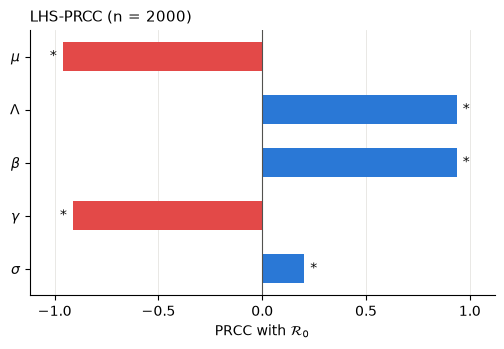

In [7]:
ax = res_prcc.plot()              # * marca p < 0.05
ax.figure.savefig("outputs/02_prcc_seir.png", dpi=200, bbox_inches="tight")

Las muestras quedan guardadas en `samples` y `output`, lo que permite inspeccionar visualmente la monotonía:

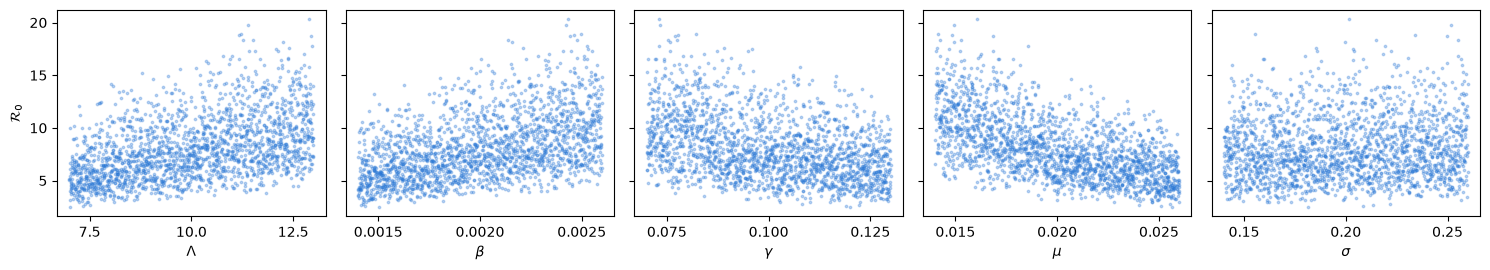

In [8]:
names = [p.name for p in res_prcc.parameters]
fig, axes = plt.subplots(1, len(names), figsize=(3 * len(names), 2.8), sharey=True)
for ax, j, name in zip(axes, range(len(names)), names):
    ax.scatter(res_prcc.samples[:, j], res_prcc.output, s=3, alpha=0.3, color="#2a78d6")
    ax.set_xlabel(f"${sp.latex(res_prcc.parameters[j])}$")
    ax.locator_params(axis="x", nbins=3)          # pocas marcas: evita que se superpongan
axes[0].set_ylabel(r"$\mathcal{R}_0$")
fig.tight_layout()
fig.savefig("outputs/02_dispersion_prcc_seir.png", dpi=200, bbox_inches="tight")

La tabla en LaTeX (o en Markdown, para el cuaderno) está lista para pegar en un artículo:

In [9]:
display(Markdown(res_prcc.to_latex("markdown")))
print(res_prcc.to_latex())        # versión para el documento (\begin{table} ... \end{table})

LHS-PRCC, $n = 2000$ (2000 evaluations of $\mathcal{R}_0$)

| Parameter | Distribution | PRCC | $p$ |
|---|---|---:|---:|
| $\mu$ | uniform [0.014, 0.026] | -0.959 | <0.001 |
| $\Lambda$ | uniform [7, 13] | 0.936 | <0.001 |
| $\beta$ | uniform [0.0014, 0.0026] | 0.936 | <0.001 |
| $\gamma$ | uniform [0.07, 0.13] | -0.911 | <0.001 |
| $\sigma$ | uniform [0.14, 0.26] | 0.201 | <0.001 |

\begin{table}[ht]
\centering
\caption{LHS-PRCC, $n = 2000$ (2000 evaluations of $\mathcal{R}_0$)}
\begin{tabular}{llrr}
\hline
Parameter & Distribution & PRCC & $p$ \\
\hline
$\mu$ & uniform [0.014, 0.026] & -0.959 & <0.001 \\
$\Lambda$ & uniform [7, 13] & 0.936 & <0.001 \\
$\beta$ & uniform [0.0014, 0.0026] & 0.936 & <0.001 \\
$\gamma$ & uniform [0.07, 0.13] & -0.911 & <0.001 \\
$\sigma$ & uniform [0.14, 0.26] & 0.201 & <0.001 \\
\hline
\end{tabular}
\end{table}


### 1.3 Índices de Sobol

Se usan las mismas distribuciones. El costo es $n(k+2)$ evaluaciones de $\mathcal{R}_0$, con $n$ potencia de 2 y $k$ parámetros que varían. Los intervalos son bootstrap al 95 %.

In [10]:
res_sobol = seir.sobol_indices(baseline=base, spread=0.3, n=2**12, seed=1)
res_sobol

GlobalSensitivityResult: Sobol, output R0, n = 4096 (28672 evaluations)
parameter                  S1               IC S1                  ST               IC ST
mu                     0.3651    [0.3396, 0.3899]              0.3985    [0.3785, 0.4182]
beta                   0.2139    [0.1956, 0.2348]              0.2362    [0.2242, 0.2491]
Lambda                 0.2131    [0.1920, 0.2302]              0.2359    [0.2243, 0.2479]
gamma                  0.1594    [0.1424, 0.1760]              0.1792    [0.1682, 0.1886]
sigma                  0.0019    [0.0000, 0.0040]              0.0020    [0.0019, 0.0021]

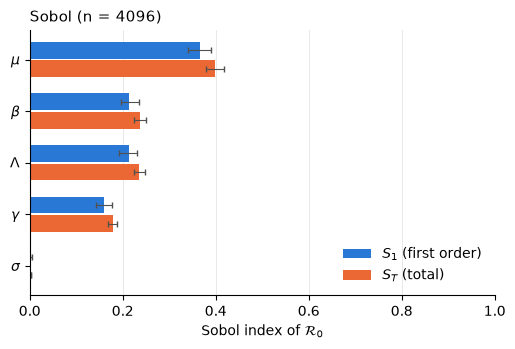

In [11]:
ax = res_sobol.plot()
ax.figure.savefig("outputs/02_sobol_seir.png", dpi=200, bbox_inches="tight")

$\sum_i S_{1,i} < 1$ y $S_T > S_1$ indican interacciones: $\mathcal{R}_0$ es un cociente de productos, de modo que el efecto de un parámetro depende del valor de los demás. La diferencia crece con la amplitud de los rangos:

In [12]:
for spread in (0.1, 0.3, 0.6, 0.9):
    r = seir.sobol_indices(baseline=base, spread=spread, n=2**12, seed=1, confidence_level=None)
    print(f"±{spread:.0%}:  sum(S1) = {r.indices['S1'].sum():.3f},  "
          f"max(ST - S1) = {(r.indices['ST'] - r.indices['S1']).max():.3f}")

±10%:  sum(S1) = 0.995,  max(ST - S1) = 0.004
±30%:  sum(S1) = 0.953,  max(ST - S1) = 0.033
±60%:  sum(S1) = 0.804,  max(ST - S1) = 0.157
±90%:  sum(S1) = 0.523,  max(ST - S1) = 0.542


### 1.4 Distribuciones a medida

Además de `(low, high)` (uniforme) se aceptan `("loguniform", low, high)`, `("normal", media, de)`, `("truncnormal", media, de, low, high)`, `("triangular", low, moda, high)` o cualquier distribución congelada de `scipy.stats`. Los parámetros de `fixed` se mantienen constantes.

In [13]:
dists = {
    "beta":  ("loguniform", 1e-3, 4e-3),                 # varios órdenes de magnitud
    "mu":    ("truncnormal", 0.02, 0.005, 0.005, 0.05),  # normal truncada para que mu > 0
    "gamma": (0.05, 0.2),                                # uniforme
}
seir.sobol_indices(dists, fixed={"Lambda": 10, "sigma": 0.2}, n=2**12, seed=1)

GlobalSensitivityResult: Sobol, output R0, n = 4096 (20480 evaluations)
parameter                  S1               IC S1                  ST               IC ST
mu                     0.3138    [0.2719, 0.3682]              0.4243    [0.3795, 0.4914]
beta                   0.3075    [0.2760, 0.3397]              0.4073    [0.3719, 0.4427]
gamma                  0.2362    [0.2093, 0.2670]              0.3376    [0.3074, 0.3785]
fixed: {'Lambda': 10.0, 'sigma': 0.2}
note: sum(S1) = 0.857: about 14% of the variance comes from parameter interactions (see ST - S1).

## 2. Del índice local al global: Ross-Macdonald

$$
\begin{cases}
\dfrac{dS_h}{dt} = \Lambda_h - a b_h \dfrac{S_h I_v}{N_h} - \mu_h S_h \\[6pt]
\dfrac{dI_h}{dt} = a b_h \dfrac{S_h I_v}{N_h} - (\gamma + \mu_h) I_h \\[6pt]
\dfrac{dR_h}{dt} = \gamma I_h - \mu_h R_h \\[6pt]
\dfrac{dS_v}{dt} = \Lambda_v - a b_v \dfrac{S_v I_h}{N_h} - \mu_v S_v \\[6pt]
\dfrac{dI_v}{dt} = a b_v \dfrac{S_v I_h}{N_h} - \mu_v I_v
\end{cases}
$$

Con $\gamma$ y $\mu_h$ fijos, $\mathcal{R}_0 = c\prod_i p_i^{a_i}$ es un monomio. Entonces $\Upsilon_{p_i} = a_i$ en todo punto y $\log\mathcal{R}_0 = \log c + \sum_i a_i \log p_i$ es aditivo. Si los parámetros son log-uniformes e independientes, los índices de Sobol de $\log\mathcal{R}_0$ son exactamente
$$
S_{1,i} = S_{T,i} = \frac{a_i^2\,\mathrm{Var}(\log p_i)}{\sum_j a_j^2\,\mathrm{Var}(\log p_j)},
\qquad \mathrm{Var}(\log p_i) = \frac{\left(\log(b_i/a'_i)\right)^2}{12}
\ \text{para}\ p_i \sim \mathrm{LogU}(a'_i, b_i).
$$
El índice global combina la elasticidad local $a_i$ con la incertidumbre del parámetro.

In [14]:
rm = R0Model('''
    dS_h/dt = Lambda_h - a*b_h*S_h*I_v/N_h - mu_h*S_h
    dI_h/dt = a*b_h*S_h*I_v/N_h - (gamma + mu_h)*I_h
    dR_h/dt = gamma*I_h - mu_h*R_h
    dS_v/dt = Lambda_v - a*b_v*S_v*I_h/N_h - mu_v*S_v
    dI_v/dt = a*b_v*S_v*I_h/N_h - mu_v*I_v
''', infected=["I_h", "I_v"])
rm.R0

sqrt(Lambda_h)*sqrt(Lambda_v)*a*sqrt(b_h)*sqrt(b_v)/(N_h*sqrt(mu_h)*mu_v*sqrt(gamma + mu_h))

In [15]:
ranges = {"a": (0.1, 0.5), "b_h": (0.1, 0.9), "b_v": (0.1, 0.9), "Lambda_h": (50, 200),
          "Lambda_v": (1000, 10000), "mu_v": (0.05, 0.2), "N_h": (2000, 8000)}
fixed = {"gamma": 0.1, "mu_h": 0.02}

# Elasticidades locales (constantes: no dependen del punto)
point = {**{p: np.sqrt(lo * hi) for p, (lo, hi) in ranges.items()}, **fixed}
upsilon = {str(p): v for p, v in rm.sensitivity_indices(point).items()}

# Índices de Sobol de log R0 y su valor analítico
res_rm = rm.sobol_indices({p: ("loguniform",) + r for p, r in ranges.items()},
                          fixed=fixed, n=2**13, seed=2, log_output=True)
w = {p: upsilon[p]**2 * np.log(hi / lo)**2 / 12 for p, (lo, hi) in ranges.items()}
total = sum(w.values())

rows = ["| $p$ | $\\Upsilon_p$ | $S_1$ | $S_T$ | analítico |", "|---|---:|---:|---:|---:|"]
for p in res_rm.ranking():
    r = res_rm[p]
    rows.append(f"| ${sp.latex(sp.Symbol(p))}$ | {upsilon[p]:+.2f} | {r['S1']:.3f} | {r['ST']:.3f} | {w[p]/total:.3f} |")
display(Markdown("\n".join(rows)))

| $p$ | $\Upsilon_p$ | $S_1$ | $S_T$ | analítico |
|---|---:|---:|---:|---:|
| $a$ | +1.00 | 0.243 | 0.243 | 0.243 |
| $N_{h}$ | -1.00 | 0.180 | 0.180 | 0.180 |
| $\mu_{v}$ | -1.00 | 0.180 | 0.180 | 0.180 |
| $\Lambda_{v}$ | +0.50 | 0.124 | 0.124 | 0.124 |
| $b_{v}$ | +0.50 | 0.113 | 0.113 | 0.113 |
| $b_{h}$ | +0.50 | 0.113 | 0.113 | 0.113 |
| $\Lambda_{h}$ | +0.50 | 0.045 | 0.045 | 0.045 |

Los exponentes $1/2$ de $b_h, b_v, \Lambda_h, \Lambda_v$ reflejan la convención de la raíz cuadrada (radio espectral de $K = FV^{-1}$). Con la otra convención ($\mathcal{R}_0^2$, el número de casos en dos generaciones) todas las elasticidades se duplican, pero los índices de Sobol de $\log\mathcal{R}_0$ no cambian, porque son razones de varianzas.

## 3. Cuando el PRCC falla: dependencia no monótona

Si la transmisibilidad depende de un factor $a(1-a)$, con $a \in (0, 1)$,
$$
\frac{dS}{dt} = \Lambda - \beta a(1-a) SI - \mu S, \qquad
\frac{dI}{dt} = \beta a(1-a) SI - (\gamma+\mu) I,
\qquad
\mathcal{R}_0 = \frac{\Lambda\beta a(1-a)}{\mu(\gamma+\mu)},
$$
$\mathcal{R}_0$ crece y luego decrece en $a$. El PRCC de $a$ es cercano a 0 aunque $a$ domine la variabilidad de $\mathcal{R}_0$; la librería lo detecta con la derivada simbólica y emite una advertencia. Los índices de Sobol, que no suponen monotonía, sí identifican a $a$.

In [16]:
nm = R0Model('''
    dS/dt = Lambda - beta*a*(1 - a)*S*I - mu*S
    dI/dt = beta*a*(1 - a)*S*I - (gamma + mu)*I
''', infected=["I"])

dists_nm = {"a": (0.01, 0.99), "beta": (1, 2)}
fixed_nm = {"Lambda": 1, "mu": 0.1, "gamma": 0.2}
nm.prcc(dists_nm, fixed=fixed_nm, n=1000, seed=0)

/tmp/ipykernel_1782/3467731586.py:8: UserWarning: R0 is not monotone in ['a'] over the sample; their PRCC can underestimate their influence. Use Sobol indices for them.
  nm.prcc(dists_nm, fixed=fixed_nm, n=1000, seed=0)


GlobalSensitivityResult: LHS-PRCC, output R0, n = 1000 (1000 evaluations)
parameter                PRCC                   p  monotonic
beta                   0.4113              <0.001  True
a                     -0.0059               0.853  False
fixed: {'Lambda': 1.0, 'gamma': 0.2, 'mu': 0.1}
note: R0 is not monotone in ['a'] over the sample; their PRCC can underestimate their influence. Use Sobol indices for them.

In [17]:
nm.sobol_indices(dists_nm, fixed=fixed_nm, n=2**12, seed=0)

GlobalSensitivityResult: Sobol, output R0, n = 4096 (16384 evaluations)
parameter                  S1               IC S1                  ST               IC ST
a                      0.8028    [0.7672, 0.8391]              0.8323    [0.8046, 0.8668]
beta                   0.1674    [0.1492, 0.1852]              0.1973    [0.1867, 0.2079]
fixed: {'Lambda': 1.0, 'gamma': 0.2, 'mu': 0.1}

## Recomendaciones de uso

* Reporte el PRCC solo para parámetros con `monotonic = True`; en caso contrario use Sobol.
* Para los índices de Sobol, aumente $n$ hasta que los intervalos de confianza sean estrechos; valores levemente negativos de $S_1$ en parámetros poco influyentes son ruido de Monte Carlo.
* Ambos métodos suponen parámetros independientes; si hay restricciones entre ellos (por ejemplo $N = \Lambda/\mu$), parametrice el modelo de forma que las cantidades muestreadas sean independientes.
* Fije `seed` para que los resultados sean reproducibles.

## Referencias

* Marino, S., Hogue, I. B., Ray, C. J., & Kirschner, D. E. (2008). A methodology for performing global uncertainty and sensitivity analysis in systems biology. *Journal of Theoretical Biology*, 254(1), 178-196.
* Saltelli, A., Annoni, P., Azzini, I., Campolongo, F., Ratto, M., & Tarantola, S. (2010). Variance based sensitivity analysis of model output. Design and estimator for the total sensitivity index. *Computer Physics Communications*, 181(2), 259-270.
* Sobol', I. M. (2001). Global sensitivity indices for nonlinear mathematical models and their Monte Carlo estimates. *Mathematics and Computers in Simulation*, 55(1-3), 271-280.
* Chitnis, N., Hyman, J. M., & Cushing, J. M. (2008). Determining important parameters in the spread of malaria through the sensitivity analysis of a mathematical model. *Bulletin of Mathematical Biology*, 70(5), 1272-1296.